In [2]:
import xarray as xr
from pathlib import Path
from xhistogram.xarray import histogram as xhist
import numpy as np

In [2]:
from dask.distributed import Client
client = Client(n_workers=2, threads_per_worker=3, memory_limit=15e9)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 2
Total threads: 6,Total memory: 27.94 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33545,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:39943,Total threads: 3
Dashboard: http://127.0.0.1:39793/status,Memory: 13.97 GiB
Nanny: tcp://127.0.0.1:40939,


In [3]:
!echo dask dashboard :D
!echo https://jupyterhub.dkrz.de/user/$USER/levante-spawner-preset/proxy/8787/status

dask dashboard :D
https://jupyterhub.dkrz.de/user/b383184/levante-spawner-preset/proxy/8787/status


In [4]:
stores = sorted(Path("/work/bk1450/b383184/Amazon/Atlantic/data/tracks_4567").glob("Parcels_run_*_*.zarr"))
stores[:3]

[PosixPath('/work/bk1450/b383184/Amazon/Atlantic/data/tracks_4567/Parcels_run_4567_2022-06-05.zarr'),
 PosixPath('/work/bk1450/b383184/Amazon/Atlantic/data/tracks_4567/Parcels_run_4567_2022-06-10.zarr'),
 PosixPath('/work/bk1450/b383184/Amazon/Atlantic/data/tracks_4567/Parcels_run_4567_2022-06-15.zarr')]

In [5]:
ds_list = [xr.open_zarr(s) for s in stores]
ds = xr.concat(ds_list,dim='trajectory')

ds

<xarray.Dataset> Size: 42GB
Dimensions:     (trajectory: 2270000, obs: 925)
Coordinates:
  * obs         (obs) int32 4kB 0 1 2 3 4 5 6 7 ... 918 919 920 921 922 923 924
  * trajectory  (trajectory) int64 18MB 0 1 2 3 4 5 ... 9995 9996 9997 9998 9999
Data variables:
    lat         (trajectory, obs) float32 8GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    lon         (trajectory, obs) float32 8GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    time        (trajectory, obs) datetime64[ns] 17GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    z           (trajectory, obs) float32 8GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        JITParticleAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

In [6]:
num_valid_obs_steps = int(ds.lat.notnull().any('trajectory').sum().compute().data[()])
ds = ds.isel(obs=slice(None, num_valid_obs_steps))
ds

<xarray.Dataset> Size: 34GB
Dimensions:     (trajectory: 2270000, obs: 741)
Coordinates:
  * obs         (obs) int32 3kB 0 1 2 3 4 5 6 7 ... 734 735 736 737 738 739 740
  * trajectory  (trajectory) int64 18MB 0 1 2 3 4 5 ... 9995 9996 9997 9998 9999
Data variables:
    lat         (trajectory, obs) float32 7GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    lon         (trajectory, obs) float32 7GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    time        (trajectory, obs) datetime64[ns] 13GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    z           (trajectory, obs) float32 7GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        JITParticleAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

In [7]:
import numpy as np

In [8]:
ds = ds.assign(start_time=ds.time.isel(obs=0).compute())
ds = ds.assign(start_year=ds.start_time.dt.year)
ds = ds.assign(start_month=ds.start_time.dt.month)
ds = ds.assign(start_day=ds.start_time.dt.day)

In [9]:
np.unique((np.minimum(np.ceil(ds.start_day / 5), 6)*5))

array([ 5., 10., 15., 20., 25., 30.])

In [10]:
ds['start_day'] = (np.minimum(np.ceil(ds.start_day / 5), 6)*5)
ds

<xarray.Dataset> Size: 34GB
Dimensions:      (trajectory: 2270000, obs: 741)
Coordinates:
  * obs          (obs) int32 3kB 0 1 2 3 4 5 6 7 ... 734 735 736 737 738 739 740
  * trajectory   (trajectory) int64 18MB 0 1 2 3 4 ... 9995 9996 9997 9998 9999
Data variables:
    lat          (trajectory, obs) float32 7GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    lon          (trajectory, obs) float32 7GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    time         (trajectory, obs) datetime64[ns] 13GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    z            (trajectory, obs) float32 7GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    start_time   (trajectory) datetime64[ns] 18MB 2022-06-05 ... 2025-07-19
    start_year   (trajectory) int64 18MB 2022 2022 2022 2022 ... 2025 2025 2025
    start_month  (trajectory) int64 18MB 6 6 6 6 6 6 6 6 6 ... 7 7 7 7 7 7 7 7 7
    start_day    (trajectory) float64 18MB 5.0 5.0 5.0 5.0 ... 20.0 20.0 20.0
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        JITParticleAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

In [11]:
lat_min=ds.lat.min().compute().data[()]
lon_min=ds.lon.min().compute().data[()]

lat_max=ds.lat.max().compute().data[()]
lon_max=ds.lon.max().compute().data[()]

### Hist Count

In [ ]:
lat_bins = np.linspace(lat_min, lat_max, 30)
lon_bins = np.linspace(lon_min, lon_max, 30)

In [ ]:
def calc_hist(ds):
    return xhist(
        ds.lon,
        ds.lat,
        bins=[lon_bins, lat_bins],
        dim=["trajectory", ],
        bin_dim_suffix=""
    )

In [ ]:
# calc hist for each start year / start month
hist = ds.groupby(["start_year", "start_month"]).apply(calc_hist)

# aggregate obs into 5 day bins (with 4 steps each day), skipping the initial positions
hist = hist.isel(obs=slice(1, None)).coarsen(obs=4 * 5, boundary="trim").sum()

# compute and store to file
hist.drop_encoding().compute().to_netcdf("_hist5days.nc")

### Hist Depth

In [20]:
def calc_hist_depth(ds):
    depth_sum = xhist(
        ds.lon, ds.lat,
        bins=[lon_bins, lat_bins],
        dim=["trajectory"],              # reduce over particles only
        weights=ds.z,                # sum of depth in each bin
        bin_dim_suffix=""
    ).rename("depth_sum")

    count = xhist(
        ds.lon, ds.lat,
        bins=[lon_bins, lat_bins],
        dim=["trajectory"],
        bin_dim_suffix=""
    ).rename("count")

    # return both so we can aggregate over obs later
    return xr.Dataset(dict(depth_sum=depth_sum, count=count))

In [ ]:
H = ds.groupby(["start_year", "start_month", "start_day"]).apply(calc_hist_depth)

# same coarsening you used for hist
H = H.isel(obs=slice(1, None))  # skip initial positions if needed
H5 = H.coarsen(obs=4*5, boundary="trim").sum()

In [ ]:
# mean depth per bin over the 5-day window
hist_depth = xr.where(H5["count"] > 0, H5["depth_sum"] / H5["count"], np.nan).rename("depth_mean")
hist_depth.drop_encoding().compute().to_netcdf("_hist_5day_depth.nc")

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 18.70 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [3]:
hist_depth = xr.open_dataset("_hist_5day_depth.nc").compute().depth_mean
hist_depth

<xarray.DataArray 'depth_mean' (obs: 37, lon: 29, lat: 29, start_year: 4,
                                start_month: 12, start_day: 6)> Size: 72MB
array([[[[[[        nan,         nan,         nan,         nan,
                    nan,         nan],
           [        nan,         nan,         nan,         nan,
                    nan,         nan],
           [        nan,         nan,         nan,         nan,
                    nan,         nan],
           ...,
           [        nan,         nan,         nan,         nan,
                    nan,         nan],
           [        nan,         nan,         nan,         nan,
                    nan,         nan],
           [        nan,         nan,         nan,         nan,
                    nan,         nan]],

          [[        nan,         nan,         nan,         nan,
                    nan,         nan],
           [        nan,         nan,         nan,         nan,
                    nan,         nan],
           [        nan,         nan,         nan,         nan,
                    nan,         nan],
...
           [        nan,         nan,         nan,         nan,
                    nan,         nan],
           [        nan,         nan,         nan,         nan,
                    nan,         nan],
           [        nan,         nan,         nan,         nan,
                    nan,         nan]],

          [[        nan,         nan,         nan,         nan,
                    nan,         nan],
           [        nan,         nan,         nan,         nan,
                    nan,         nan],
           [        nan,         nan,         nan,         nan,
                    nan,         nan],
           ...,
           [        nan,         nan,         nan,         nan,
                    nan,         nan],
           [        nan,         nan,         nan,         nan,
                    nan,         nan],
           [        nan,         nan,         nan,         nan,
                    nan,         nan]]]]]], shape=(37, 29, 29, 4, 12, 6))
Coordinates:
  * start_year   (start_year) int64 32B 2022 2023 2024 2025
  * start_month  (start_month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * start_day    (start_day) float64 48B 5.0 10.0 15.0 20.0 25.0 30.0
  * obs          (obs) float64 296B 10.5 30.5 50.5 70.5 ... 690.5 710.5 730.5
  * lon          (lon) float32 116B -87.67 -84.59 -81.51 ... -4.615 -1.539
  * lat          (lat) float32 116B -3.942 -2.754 -1.566 ... 26.95 28.14 29.33

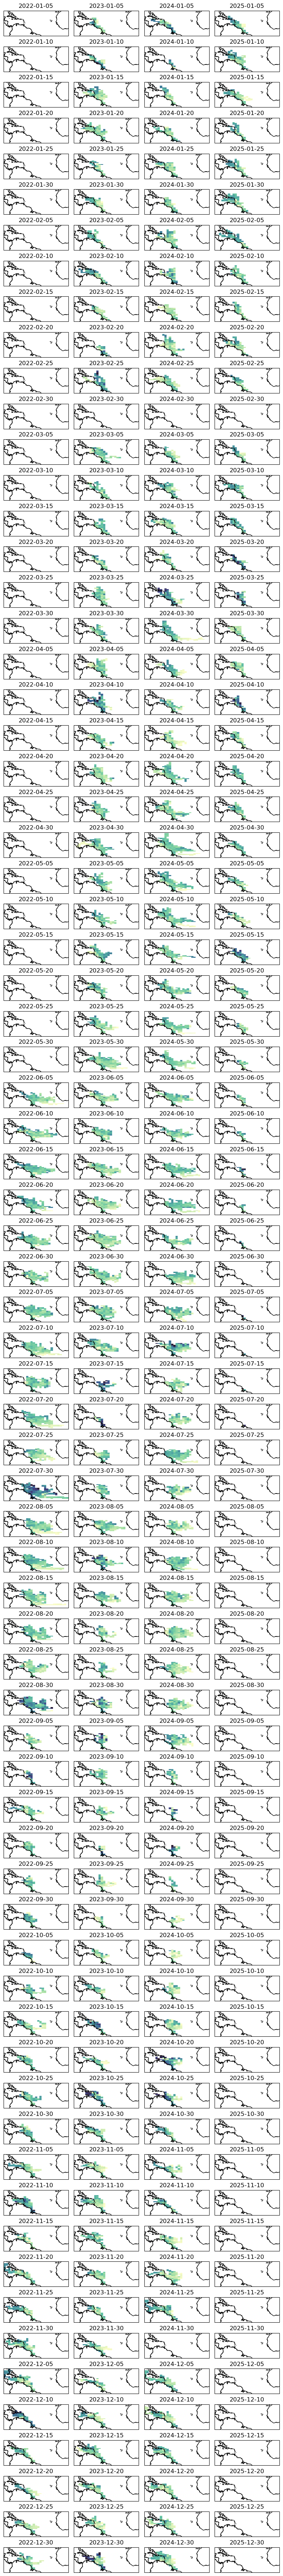

In [6]:
import cartopy
import matplotlib.pyplot as plt
import cmocean as cm
# Get unique sorted values
unique_years = sorted(np.unique(hist_depth.start_year.data))
unique_months = sorted(np.unique(hist_depth.start_month.data))
unique_days = sorted(np.unique(hist_depth.start_day.data))  # e.g., [1,6,11,16,21] or whatever your 5 days are

num_years = len(unique_years)
num_months = len(unique_months)
num_days = len(unique_days)  # Should be 5

# Create subplots: rows = months * days (grouped by month), columns = years
fig, ax = plt.subplots(
    num_months * num_days, num_years,
    figsize=(num_years * 2, num_months * num_days),  # Adjust size dynamically
    subplot_kw={"projection": cartopy.crs.PlateCarree()},
)

np.seterr(divide='ignore')  # Don't warn on np.log10 on invalid or 0 data

for nyr, syr in enumerate(unique_years):
    for nmon, smon in enumerate(unique_months):
        for nday, sday in enumerate(unique_days):
            # Calculate row index: group days within each month
            row = nmon * num_days + nday
            _ax = ax[row, nyr]
            
            # Select and plot (assuming 'obs' is the dimension to sum over)
            data = hist_depth.sel(start_year=syr, start_month=smon, start_day=sday).mean("obs")
            np.log10(data).plot(
                x="lon", y="lat",
                transform=cartopy.crs.PlateCarree(), ax=_ax,
                add_colorbar=False,cmap=cm.cm.deep_r
            ) ## change here the log10 by adding nan to 0s
            _ax.set_title(f"{int(syr):04d}-{int(smon):02d}-{int(sday):02d}")
            _ax.coastlines()

fig.tight_layout()
# fig.savefig('particles_5days_depth.pdf', dpi=300, bbox_inches='tight')